# Diagnóstico da normal de precipitação CHELSA 1991–2020 (Brasil)

**Objetivo:** verificar se a normal `chelsa_brasil_normal_1991_2020` tem erro, de que tipo e onde, usando a normal CHELSA 1981–2010 como controle.

**Lógica:** a diferença entre duas normais mistura **mudança climática real** com **erro de processamento**. Para separar os dois, usamos produtos independentes (CHIRPS e TerraClimate) calculados para **os mesmos dois períodos**:

$$DR = \frac{P^{CHELSA}_{91-20} / P^{CHELSA}_{81-10}}{P^{REF}_{91-20} / P^{REF}_{81-10}} = \frac{B_{91}}{B_{81}}, \qquad B_{p} = \frac{P^{CHELSA}_{p}}{P^{REF}_{p}}$$

- O viés próprio do CHELSA em relação à referência (orografia, interpolação) aparece nos dois períodos e **se cancela** em $DR$.
- $DR \approx 1$: a mudança entre as normais do CHELSA acompanha a da referência, **sem erro**.
- $DR$ muito diferente de 1: **inconsistência**. Comparar $B_{91}$ com $B_{81}$ mostra qual das duas normais se afastou da referência.

**Etapas:**
1. Inventário dos assets (tipo, bandas, dtype, escala, estatísticas brutas, saturação)
2. Padronização (12 bandas mensais) e detecção do fator de escala
3. Referências independentes: CHIRPS e TerraClimate, 1981–2010 e 1991–2020
4. Razões anuais e mensais, ciclo sazonal, estatísticas por UF, mapas, dispersões
5. Diagnóstico automático

In [1]:
# !pip install -q earthengine-api   # já vem instalado no Colab
import re, io, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import requests
import ee
from IPython.display import display, Markdown

PROJECT = 'fcoliveira'   # projeto Cloud vinculado ao GEE (ajuste se necessário)
try:
    ee.Initialize(project=PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT)
print('GEE:', ee.String('conectado').getInfo())

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


GEE: conectado


## 1. Parâmetros

In [2]:
ASSET_8110 = 'projects/fcoliveira/assets/CHELSA/CHELSA_pr_1981-2010'
# Asset dedicado de pr (12 bandas, pr_01..pr_12), gerado por gerar_normal_multibanda.py e
# subido separadamente do tas/pet (não há mais um único asset combinado de 36 bandas).
ASSET_9120 = 'projects/fcoliveira/assets/chelsa_brasil_pr_normal_1991_2020'

# Fator de escala dos valores brutos: 'auto' (detecta comparando com o CHIRPS do mesmo período)
# ou um número (ex.: 0.01 = escala padrão da precipitação no CHELSA V2.1)
FATOR_8110 = 'auto'
FATOR_9120 = 'auto'

# Ordem manual das bandas (jan..dez), caso a detecção automática pelo nome falhe
BANDAS_8110 = None   # ex.: ['b1', 'b2', ..., 'b12']
BANDAS_9120 = None   # asset já tem só as 12 bandas de pr (pr_01..pr_12); detecção automática pelo nome

ESCALA = 10000          # m, estatísticas regionais
ESCALA_AMOSTRA = 5000   # m, amostragem de pixels
N_AMOSTRAS = 4000
LIMIAR_ANUAL = 0.15     # |DR - 1| acima disso = pixel suspeito (anual)
LIMIAR_MENSAL = 0.30    # idem, mensal
REF_MIN_MENSAL = 10     # mm; meses com referência abaixo disso são mascarados nas razões mensais

brasil_fc = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
brasil = brasil_fc.geometry().simplify(1000)
ufs = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
bbox_coords = brasil.bounds().coordinates().getInfo()[0]
LON = [p[0] for p in bbox_coords]; LAT = [p[1] for p in bbox_coords]
EXTENT = [min(LON), max(LON), min(LAT), max(LAT)]

MESES = [f'm{m:02d}' for m in range(1, 13)]
NOMES_MESES = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

def rr(img, reducer, escala=ESCALA, regiao=None):
    return img.reduceRegion(reducer=reducer, geometry=regiao or brasil, scale=escala,
                            maxPixels=1e13, bestEffort=True, tileScale=4).getInfo()

## 2. Inventário dos assets

In [3]:
def inspecionar(asset_id):
    info = ee.data.getAsset(asset_id)
    tipo = info.get('type')
    print(f'\n=== {asset_id}\nTipo: {tipo}')
    if tipo == 'IMAGE':
        img = ee.Image(asset_id)
        bandas = img.bandNames().getInfo()
        proj = img.select(0).projection()
        tipos = img.bandTypes().getInfo()
        print('Nº de bandas:', len(bandas))
        print('Bandas:', bandas)
        print('CRS:', proj.crs().getInfo(), '| escala nominal (m):', round(proj.nominalScale().getInfo(), 1))
        print('Tipo de dado (1ª banda):', tipos[bandas[0]])
        props = img.toDictionary().getInfo()
        if props:
            print('Propriedades:', json.dumps(props, ensure_ascii=False)[:1500])
        return {'tipo': tipo, 'bandas': bandas, 'dtype': tipos}
    if tipo == 'IMAGE_COLLECTION':
        col = ee.ImageCollection(asset_id)
        n = col.size().getInfo()
        ids = col.aggregate_array('system:index').getInfo()
        t = col.aggregate_array('system:time_start').getInfo()
        bandas = col.first().bandNames().getInfo()
        tipos = col.first().bandTypes().getInfo()
        print('Nº de imagens:', n, '| bandas da 1ª imagem:', bandas)
        print('Índices:', ids[:5], '...', ids[-3:])
        if t:
            d = pd.to_datetime(t, unit='ms')
            print('Período:', d.min().date(), '→', d.max().date())
        print('Tipo de dado (1ª imagem):', tipos[bandas[0]])
        return {'tipo': tipo, 'n': n, 'ids': ids, 'time': t, 'bandas': bandas, 'dtype': tipos}
    raise ValueError(f'Tipo de asset não tratado: {tipo}')

info81 = inspecionar(ASSET_8110)
info91 = inspecionar(ASSET_9120)


=== projects/fcoliveira/assets/CHELSA/CHELSA_pr_1981-2010
Tipo: IMAGE


Nº de bandas: 12
Bandas: ['pr_01', 'pr_02', 'pr_03', 'pr_04', 'pr_05', 'pr_06', 'pr_07', 'pr_08', 'pr_09', 'pr_10', 'pr_11', 'pr_12']


CRS: EPSG:4326 | escala nominal (m): 1000
Tipo de dado (1ª banda): {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 65535}


Propriedades: {"bands": "pr_01..pr_12", "dataset": "CHELSA", "period": "1981-2010", "type": "monthly_climatology", "units": "mm", "variable": "pr"}



=== projects/fcoliveira/assets/chelsa_brasil_normal_1991_2020
Tipo: IMAGE


Nº de bandas: 36
Bandas: ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'b10', 'b11', 'b12', 'b13', 'b14', 'b15', 'b16', 'b17', 'b18', 'b19', 'b20', 'b21', 'b22', 'b23', 'b24', 'b25', 'b26', 'b27', 'b28', 'b29', 'b30', 'b31', 'b32', 'b33', 'b34', 'b35', 'b36']


CRS: EPSG:4326 | escala nominal (m): 927.7
Tipo de dado (1ª banda): {'type': 'PixelType', 'precision': 'float'}


## 3. Padronização em 12 bandas mensais (valores brutos)

In [4]:
def mes_do_nome(nome):
    s = re.sub(r'(19|20)\d{2}', ' ', str(nome))     # remove anos (1981, 2010...)
    for n in re.findall(r'\d+', s):
        v = int(n)
        if 1 <= v <= 12:
            return v
    return None

def ordenar(nomes, manual=None):
    if manual:
        return list(manual)
    if len(nomes) != 12:
        return None
    meses = [mes_do_nome(b) for b in nomes]
    if None not in meses and sorted(meses) == list(range(1, 13)):
        return [b for _, b in sorted(zip(meses, nomes))]
    print('  ! Mês não identificado pelos nomes; usando a ordem original.')
    return list(nomes)

def padronizar(asset_id, info, manual=None, a0=None, a1=None):
    # Retorna (imagem mensal m01..m12 ou None, imagem anual) em valores brutos
    if info['tipo'] == 'IMAGE':
        img = ee.Image(asset_id)
        ordem = ordenar(info['bandas'], manual)
        if ordem is None:
            b = info['bandas'][0]
            print(f'  ! {len(info["bandas"])} banda(s): usando "{b}" como total anual.')
            return None, img.select([b]).rename('anual').toFloat()
        print('  Mapeamento banda → mês:', dict(zip(ordem, MESES)))
        mensal = img.select(ordem).rename(MESES).toFloat()
    else:
        col = ee.ImageCollection(asset_id).select([0])
        if info['n'] == 12:
            if info['time'] and len(set(info['time'])) == 12:
                mensal = col.sort('system:time_start').toBands().rename(MESES).toFloat()
                print('  12 imagens ordenadas por system:time_start')
            else:
                ordem = ordenar(info['ids'], manual)
                print('  Mapeamento índice → mês:', dict(zip(ordem, MESES)))
                imgs = [col.filter(ee.Filter.eq('system:index', i)).first() for i in ordem]
                mensal = ee.ImageCollection(imgs).toBands().rename(MESES).toFloat()
        else:
            # Série mensal: checa completude e calcula a climatologia
            d = pd.to_datetime(info['time'], unit='ms')
            sel = d[(d.year >= a0) & (d.year <= a1)]
            cont = pd.Series(sel.month).value_counts().reindex(range(1, 13), fill_value=0)
            print(f'  Série mensal: {len(sel)} imagens entre {a0} e {a1} (esperado {12*(a1-a0+1)})')
            print('  Anos por mês:', dict(zip(NOMES_MESES, cont.values)))
            faltam = sorted(set(range(a0, a1 + 1)) - set(sel.year))
            if faltam:
                print('  ! ANOS AUSENTES:', faltam)
            col = col.filterDate(f'{a0}-01-01', f'{a1 + 1}-01-01')
            mensal = ee.Image.cat([col.filter(ee.Filter.calendarRange(m, m, 'month')).mean().rename(MESES[m - 1])
                                   for m in range(1, 13)]).toFloat()
    return mensal, mensal.reduce(ee.Reducer.sum()).rename('anual')

print('1981–2010'); m81_raw, a81_raw = padronizar(ASSET_8110, info81, BANDAS_8110, 1981, 2010)
print('1991–2020'); m91_raw, a91_raw = padronizar(ASSET_9120, info91, BANDAS_9120, 1991, 2020)
MENSAL = (m81_raw is not None) and (m91_raw is not None)
print('\nAnálise mensal disponível:', MENSAL)

1981–2010
  Mapeamento banda → mês: {'pr_01': 'm01', 'pr_02': 'm02', 'pr_03': 'm03', 'pr_04': 'm04', 'pr_05': 'm05', 'pr_06': 'm06', 'pr_07': 'm07', 'pr_08': 'm08', 'pr_09': 'm09', 'pr_10': 'm10', 'pr_11': 'm11', 'pr_12': 'm12'}
1991–2020
  Mapeamento banda → mês: {'b25': 'm01', 'b26': 'm02', 'b27': 'm03', 'b28': 'm04', 'b29': 'm05', 'b30': 'm06', 'b31': 'm07', 'b32': 'm08', 'b33': 'm09', 'b34': 'm10', 'b35': 'm11', 'b36': 'm12'}

Análise mensal disponível: True


### 3.1 Estatísticas brutas e checagem de saturação
Valores iguais ao máximo em muitos pixels indicam **teto de tipo inteiro** (ex.: int16 = 32767) ou recorte indevido. Com a escala 0,01 do CHELSA, 32767 corresponde a 327,67 mm/mês, valor que a Amazônia supera na estação chuvosa.

In [5]:
def tabela_estat(img, escala=ESCALA):
    red = (ee.Reducer.min().combine(ee.Reducer.max(), sharedInputs=True)
           .combine(ee.Reducer.mean(), sharedInputs=True)
           .combine(ee.Reducer.percentile([2, 50, 98]), sharedInputs=True)
           .combine(ee.Reducer.count(), sharedInputs=True))
    d = rr(img, red, escala)
    linhas = {}
    for k, v in d.items():
        banda, est = k.rsplit('_', 1)
        linhas.setdefault(banda, {})[est] = v
    df = pd.DataFrame(linhas).T
    cols = [c for c in ['min', 'p2', 'p50', 'mean', 'p98', 'max', 'count'] if c in df.columns]
    return df[cols].reindex(img.bandNames().getInfo()).astype(float)

LIMITES_INT = {127, 255, 32767, 65535, 2147483647, 4294967295}

def checar_saturacao(img, est, info, nome):
    maxs = est['max'].tolist()
    const = ee.Image.constant(maxs).rename(img.bandNames())
    frac = pd.Series(rr(img.eq(const), ee.Reducer.mean())).reindex(est.index) * 100
    out = pd.DataFrame({'max_bruto': est['max'], '%_pixels_no_max': frac.round(3)})
    dt = list(info['dtype'].values())[0]
    print(f'{nome}: dtype = {dt}')
    alerta = out[(out['%_pixels_no_max'] > 0.1) | (out['max_bruto'].round().isin(LIMITES_INT))]
    if len(alerta):
        print('  ! POSSÍVEL SATURAÇÃO / TETO nas bandas:', list(alerta.index))
    else:
        print('  Sem indício de saturação.')
    return out, alerta

img81 = m81_raw if m81_raw is not None else a81_raw
img91 = m91_raw if m91_raw is not None else a91_raw
est81 = tabela_estat(img81); est91 = tabela_estat(img91)
display(Markdown('**CHELSA 1981–2010, valores brutos**')); display(est81.round(2))
display(Markdown('**CHELSA 1991–2020, valores brutos**')); display(est91.round(2))

sat81, alerta_sat81 = checar_saturacao(img81, est81, info81, 'CHELSA 1981–2010')
sat91, alerta_sat91 = checar_saturacao(img91, est91, info91, 'CHELSA 1991–2020')
display(pd.concat({'8110': sat81, '9120': sat91}, axis=1))

**CHELSA 1981–2010, valores brutos**

,min,p2,p50,mean,p98,max,count
m01,144.0,558.29,2607.95,2447.97,3823.10,5747.0,89180.0
m02,152.0,559.27,2319.32,2255.78,3822.58,5911.0,89180.0
m03,155.0,878.74,2543.91,2463.63,4271.30,6027.0,89180.0
m04,222.0,463.86,1743.40,1907.73,4047.72,5941.0,89180.0
m05,23.0,112.47,1007.07,1364.22,4078.72,7113.0,89180.0
m06,10.0,23.65,431.16,829.23,3407.42,5405.0,89180.0
m07,2.0,13.86,271.60,641.10,2894.73,5076.0,89180.0
m08,2.0,15.55,335.44,548.16,2158.57,4379.0,89180.0
m09,8.0,24.50,695.24,781.22,2023.49,3323.0,89180.0
m10,7.0,55.57,1271.49,1246.43,2422.89,3465.0,89180.0


**CHELSA 1991–2020, valores brutos**

,min,p2,p50,mean,p98,max,count
m01,14.52,53.91,250.04,233.79,370.04,529.00,89175.0
m02,17.38,54.06,234.06,226.42,378.01,609.95,89175.0
m03,19.14,69.95,237.99,236.08,421.91,589.33,89175.0
m04,0.00,0.00,154.05,153.48,401.87,611.54,89175.0
m05,0.00,0.00,66.02,107.23,390.05,631.22,89175.0
m06,0.00,0.40,13.96,59.48,306.05,524.53,89175.0
m07,0.00,0.13,7.00,43.45,250.99,475.11,89175.0
m08,0.00,0.16,8.89,34.65,188.92,427.14,89175.0
m09,0.00,0.07,24.99,44.78,170.88,339.06,89175.0
m10,0.00,0.02,51.01,74.04,215.03,321.70,89175.0


CHELSA 1981–2010: dtype = {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 65535}
  Sem indício de saturação.


CHELSA 1991–2020: dtype = {'type': 'PixelType', 'precision': 'float'}
  Sem indício de saturação.


8110                        9120                
    max_bruto %_pixels_no_max   max_bruto %_pixels_no_max
m01    5747.0           0.000  528.998413           0.000
m02    5911.0           0.000  609.951050           0.001
m03    6027.0           0.001  589.333862           0.000
m04    5941.0           0.000  611.536987           0.001
m05    7113.0           0.001  631.217712           0.000
m06    5405.0           0.000  524.525024           0.000
m07    5076.0           0.001  475.108337           0.000
m08    4379.0           0.000  427.139069           0.000
m09    3323.0           0.001  339.055725           0.000
m10    3465.0           0.001  321.696350           0.000
m11    3452.0           0.001  339.011444           0.000
m12    4940.0           0.001  410.458313           0.001

## 4. Referências independentes (CHIRPS e TerraClimate)

In [6]:
CHIRPS = ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD').select('precipitation')
TERRA = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE').select('pr')   # mm/mês, sem fator de escala

def clim_chirps(a0, a1):
    n = a1 - a0 + 1
    c = CHIRPS.filterDate(f'{a0}-01-01', f'{a1 + 1}-01-01')
    return ee.Image.cat([c.filter(ee.Filter.calendarRange(m, m, 'month')).sum().divide(n).rename(MESES[m - 1])
                         for m in range(1, 13)]).toFloat()

def clim_terra(a0, a1):
    c = TERRA.filterDate(f'{a0}-01-01', f'{a1 + 1}-01-01')
    return ee.Image.cat([c.filter(ee.Filter.calendarRange(m, m, 'month')).mean().rename(MESES[m - 1])
                         for m in range(1, 13)]).toFloat()

def anual(m):
    return m.reduce(ee.Reducer.sum()).rename('anual')

c81m, c91m = clim_chirps(1981, 2010), clim_chirps(1991, 2020)
t81m, t91m = clim_terra(1981, 2010), clim_terra(1991, 2020)
C81, C91, T81, T91 = anual(c81m), anual(c91m), anual(t81m), anual(t91m)

## 5. Fator de escala
Compara a mediana nacional do total anual bruto com a do CHIRPS do mesmo período. O fator implícito deve bater com um candidato plausível e ser **o mesmo nas duas normais**.

In [7]:
CANDIDATOS = {1: 'mm (sem escala)', 0.1: 'escala 0,1', 0.01: 'escala 0,01 (padrão CHELSA V2.1)',
              0.001: 'escala 0,001', 10: '×10', 12: '×12 (média mensal em vez de total anual)',
              30.44: '×30,44 (mm/dia → mm/mês)', 100: '×100', 1000: '×1000 (m → mm)'}

def mediana(img):
    return list(rr(img, ee.Reducer.median()).values())[0]

def detectar_fator(anual_bruto, anual_ref, nome):
    mb, mr = mediana(anual_bruto), mediana(anual_ref)
    imp = mr / mb
    melhor = min(CANDIDATOS, key=lambda f: abs(math.log(imp / f)))
    desvio = imp / melhor - 1
    print(f'{nome}: mediana bruta = {mb:,.2f} | CHIRPS = {mr:,.1f} mm | fator implícito = {imp:.4g}'
          f' → candidato {melhor} [{CANDIDATOS[melhor]}] (desvio {desvio:+.1%})')
    if abs(desvio) > 0.25:
        print('  ! Fator implícito não bate com nenhum candidato: erro não é só de unidade/escala.')
    return melhor, imp, desvio

f81_auto, imp81, dev81 = detectar_fator(a81_raw, C81, 'CHELSA 1981–2010')
f91_auto, imp91, dev91 = detectar_fator(a91_raw, C91, 'CHELSA 1991–2020')
f81 = f81_auto if FATOR_8110 == 'auto' else FATOR_8110
f91 = f91_auto if FATOR_9120 == 'auto' else FATOR_9120
print(f'\nFatores aplicados: 8110 = {f81} | 9120 = {f91}')
if f81 != f91:
    print('! As duas normais exigem fatores diferentes: forte indício de erro de escala/unidade em uma delas.')

m81 = m81_raw.multiply(f81) if m81_raw is not None else None
m91 = m91_raw.multiply(f91) if m91_raw is not None else None
A81 = a81_raw.multiply(f81).rename('anual')
A91 = a91_raw.multiply(f91).rename('anual')

CHELSA 1981–2010: mediana bruta = 18,304.00 | CHIRPS = 1,768.2 mm | fator implícito = 0.0966 → candidato 0.1 [escala 0,1] (desvio -3.4%)


CHELSA 1991–2020: mediana bruta = 1,520.30 | CHIRPS = 1,784.0 mm | fator implícito = 1.173 → candidato 1 [mm (sem escala)] (desvio +17.3%)

Fatores aplicados: 8110 = 0.1 | 9120 = 1
! As duas normais exigem fatores diferentes: forte indício de erro de escala/unidade em uma delas.


## 6. Razões anuais

In [8]:
B81, B91 = A81.divide(C81), A91.divide(C91)            # CHELSA / CHIRPS no mesmo período
R_CH, R_CHIRPS, R_TC = A91.divide(A81), C91.divide(C81), T91.divide(T81)
DR = R_CH.divide(R_CHIRPS)                             # = B91 / B81
DR_TC = R_CH.divide(R_TC)
B81_TC, B91_TC = A81.divide(T81), A91.divide(T91)

anual_img = ee.Image.cat([
    A81.rename('CHELSA_8110'), A91.rename('CHELSA_9120'),
    C81.rename('CHIRPS_8110'), C91.rename('CHIRPS_9120'),
    T81.rename('TERRA_8110'), T91.rename('TERRA_9120'),
    B81.rename('B81_chirps'), B91.rename('B91_chirps'),
    B81_TC.rename('B81_terra'), B91_TC.rename('B91_terra'),
    R_CH.rename('R_CHELSA'), R_CHIRPS.rename('R_CHIRPS'), R_TC.rename('R_TERRA'),
    DR.rename('DR_chirps'), DR_TC.rename('DR_terra')]).updateMask(A81.mask().And(A91.mask()))

tab_anual = tabela_estat(anual_img)
display(tab_anual.round(3))

susp = DR.subtract(1).abs().gt(LIMIAR_ANUAL).And(DR_TC.subtract(1).abs().gt(LIMIAR_ANUAL)).rename('suspeito')
frac_susp = list(rr(susp, ee.Reducer.mean()).values())[0] * 100
print(f'Área com |DR-1| > {LIMIAR_ANUAL} em relação a CHIRPS **e** TerraClimate: {frac_susp:.1f}% do Brasil')

,min,p2,p50,mean,p98,max,count
CHELSA_8110,387.600,592.344,1840.571,1823.564,3215.873,4793.800,89180.0
CHELSA_9120,109.505,306.181,1552.131,1437.932,3056.251,4941.909,89180.0
CHIRPS_8110,207.158,567.905,1768.087,1763.306,3032.561,3848.095,89015.0
CHIRPS_9120,191.846,535.503,1784.053,1763.667,3031.325,3781.291,89015.0
TERRA_8110,167.956,567.584,1703.923,1742.949,3031.315,3804.300,89032.0
TERRA_9120,157.507,520.134,1703.691,1735.098,3064.607,3913.433,89032.0
B81_chirps,0.585,0.861,1.046,1.041,1.296,5.509,89015.0
B91_chirps,0.072,0.235,0.923,0.788,1.202,5.871,89015.0
B81_terra,0.477,0.829,1.047,1.052,1.327,6.538,89032.0
B91_terra,0.060,0.237,0.922,0.806,1.265,5.827,89032.0


Área com |DR-1| > 0.15 em relação a CHIRPS **e** TerraClimate: 34.4% do Brasil


## 7. Análise mensal
Mostra se o problema está concentrado em **alguns meses** (ordem de bandas trocada, mês faltando, saturação na estação chuvosa).

,B81,B91,DR,DRtc,CH81,CH91,CP81,CP91,TC81,TC91
Jan,1.047,0.984,0.959,0.959,261.938,250.025,254.030,253.034,251.003,246.991
Fev,1.047,1.016,0.982,0.979,229.958,234.089,221.031,226.013,222.029,233.926
Mar,1.047,0.984,0.947,0.967,253.973,238.009,246.072,246.063,241.927,238.004
Abr,1.031,0.922,0.926,0.926,173.903,154.047,166.033,162.033,170.009,157.993
Mai,1.047,0.891,0.918,0.918,101.866,66.002,97.921,98.062,102.008,101.991
Jun,1.031,0.845,0.902,0.895,41.941,13.953,39.007,40.973,36.973,39.014
Jul,0.969,0.845,0.895,0.887,26.952,7.005,24.965,24.996,26.981,26.935
Ago,1.031,0.721,0.824,0.871,34.969,8.892,34.984,30.985,32.947,28.973
Set,1.031,0.766,0.848,0.895,68.942,24.997,64.979,60.990,60.956,54.978
Out,1.047,0.883,0.895,0.918,126.965,50.995,125.006,122.993,128.993,124.960


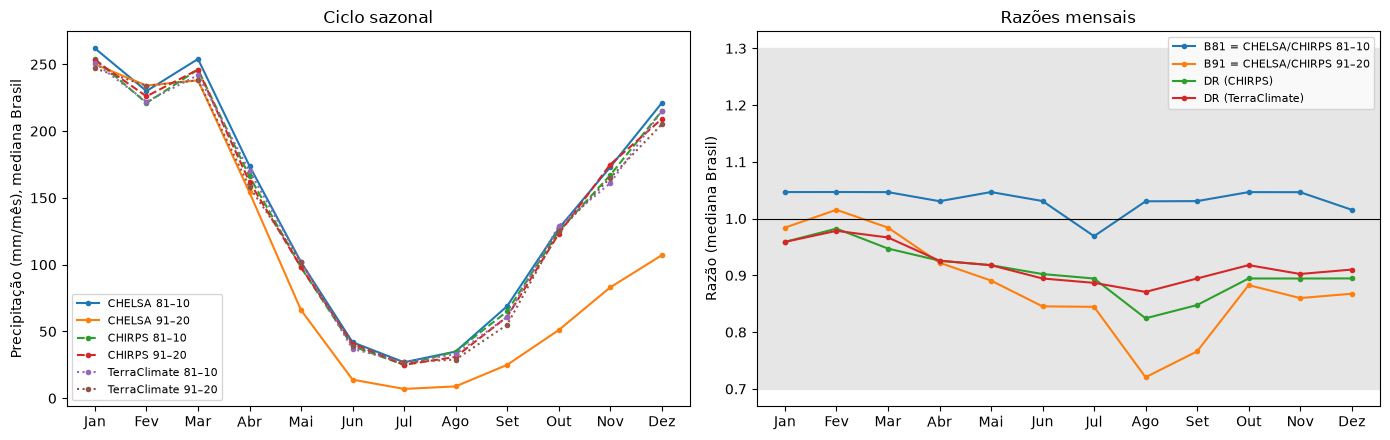

% da área com |DR-1| > 0.3 por mês:


,%
Jan,0.1
Fev,0.1
Mar,0.0
Abr,32.7
Mai,34.0
Jun,34.6
Jul,34.6
Ago,38.8
Set,39.0
Out,35.9


In [9]:
def razao(a, b, minimo=REF_MIN_MENSAL):
    return a.divide(b).updateMask(b.gte(minimo))

if MENSAL:
    B81m, B91m = razao(m81, c81m), razao(m91, c91m)
    DRm = razao(m91, m81).divide(razao(c91m, c81m))
    DRm_tc = razao(m91, m81).divide(razao(t91m, t81m))
    pref = lambda img, p: img.rename([f'{p}_{m}' for m in MESES])
    mens_img = ee.Image.cat([pref(B81m, 'B81'), pref(B91m, 'B91'), pref(DRm, 'DR'), pref(DRm_tc, 'DRtc'),
                             pref(m81, 'CH81'), pref(m91, 'CH91'), pref(c81m, 'CP81'), pref(c91m, 'CP91'),
                             pref(t81m, 'TC81'), pref(t91m, 'TC91')])
    med = pd.Series(rr(mens_img, ee.Reducer.median()))
    tab_mensal = pd.DataFrame({p: [med.get(f'{p}_{m}') for m in MESES]
                               for p in ['B81', 'B91', 'DR', 'DRtc', 'CH81', 'CH91', 'CP81', 'CP91', 'TC81', 'TC91']},
                              index=NOMES_MESES).astype(float)
    display(tab_mensal.round(3))

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for col, lab, ls in [('CH81', 'CHELSA 81–10', '-'), ('CH91', 'CHELSA 91–20', '-'),
                         ('CP81', 'CHIRPS 81–10', '--'), ('CP91', 'CHIRPS 91–20', '--'),
                         ('TC81', 'TerraClimate 81–10', ':'), ('TC91', 'TerraClimate 91–20', ':')]:
        ax[0].plot(NOMES_MESES, tab_mensal[col], ls, marker='o', ms=3, label=lab)
    ax[0].set_ylabel('Precipitação (mm/mês), mediana Brasil'); ax[0].legend(fontsize=8); ax[0].set_title('Ciclo sazonal')
    for col, lab in [('B81', 'B81 = CHELSA/CHIRPS 81–10'), ('B91', 'B91 = CHELSA/CHIRPS 91–20'),
                     ('DR', 'DR (CHIRPS)'), ('DRtc', 'DR (TerraClimate)')]:
        ax[1].plot(NOMES_MESES, tab_mensal[col], marker='o', ms=3, label=lab)
    ax[1].axhline(1, color='k', lw=0.8)
    ax[1].axhspan(1 - LIMIAR_MENSAL, 1 + LIMIAR_MENSAL, color='0.9', zorder=0)
    ax[1].set_ylabel('Razão (mediana Brasil)'); ax[1].legend(fontsize=8); ax[1].set_title('Razões mensais')
    plt.tight_layout(); plt.show()

    frac_m = pd.Series(rr(DRm.subtract(1).abs().gt(LIMIAR_MENSAL), ee.Reducer.mean())).reindex(MESES) * 100
    frac_m.index = NOMES_MESES
    print(f'% da área com |DR-1| > {LIMIAR_MENSAL} por mês:'); display(frac_m.round(1).to_frame('%'))
else:
    print('Uma das normais não tem 12 bandas mensais: análise mensal ignorada.')

### 7.1 Ciclo sazonal pixel a pixel
Correlação entre os 12 meses das duas normais e deslocamento do mês mais chuvoso. A referência (CHIRPS 91–20 × 81–10) mostra quanto isso varia naturalmente.

In [10]:
def correl_12(a, b):
    da = a.subtract(a.reduce(ee.Reducer.mean()))
    db = b.subtract(b.reduce(ee.Reducer.mean()))
    cov = da.multiply(db).reduce(ee.Reducer.sum())
    va, vb = da.pow(2).reduce(ee.Reducer.sum()), db.pow(2).reduce(ee.Reducer.sum())
    return cov.divide(va.multiply(vb).sqrt()).rename('r')

def mes_max(m):
    return m.toArray().arrayArgmax().arrayGet([0]).add(1).rename('mes_max')

def desloc(a, b):
    d = mes_max(a).subtract(mes_max(b)).abs()
    return d.min(ee.Image(12).subtract(d)).rename('desloc')

if MENSAL:
    r_ch, r_cp = correl_12(m91, m81), correl_12(c91m, c81m)
    r_91cp = correl_12(m91, c91m); r_81cp = correl_12(m81, c81m)
    d_ch, d_cp = desloc(m91, m81), desloc(c91m, c81m)
    saz = ee.Image.cat([r_ch.rename('r_CHELSA_91x81'), r_cp.rename('r_CHIRPS_91x81'),
                        r_81cp.rename('r_CHELSA81xCHIRPS81'), r_91cp.rename('r_CHELSA91xCHIRPS91'),
                        d_ch.gt(1).rename('desloc_CHELSA_gt1'), d_cp.gt(1).rename('desloc_CHIRPS_gt1')])
    tab_saz = pd.Series(rr(saz, ee.Reducer.mean())).to_frame('média Brasil')
    tab_saz.loc[['desloc_CHELSA_gt1', 'desloc_CHIRPS_gt1']] *= 100
    display(tab_saz.round(3))
    print('Linhas desloc_*: % da área em que o mês mais chuvoso muda mais de 1 mês entre as normais.')

,média Brasil
desloc_CHELSA_gt1,14.038
desloc_CHIRPS_gt1,8.900
r_CHELSA81xCHIRPS81,0.983
r_CHELSA91xCHIRPS91,0.814
r_CHELSA_91x81,0.820
r_CHIRPS_91x81,0.987


Linhas desloc_*: % da área em que o mês mais chuvoso muda mais de 1 mês entre as normais.


## 8. Estatísticas por UF

,CHELSA_8110,CHELSA_9120,CHIRPS_8110,CHIRPS_9120,B81,B91,DR_chirps,DR_terra,pct_suspeito,|DR-1|
ADM1_NAME,,,,,,,,,,
Rio Grande Do Sul,1716.218,409.894,1621.754,1665.979,1.045,0.241,0.231,0.237,100.000,0.769
Name Unknown,723.900,153.713,500.080,454.599,1.448,0.338,0.234,0.222,100.000,0.766
Santa Catarina,1867.653,557.713,1675.697,1715.737,1.088,0.313,0.288,0.286,100.000,0.712
Parana,1772.188,530.049,1604.177,1628.319,1.088,0.327,0.295,0.292,100.000,0.705
Espirito Santo,1267.928,365.097,1175.522,1138.747,1.064,0.329,0.315,0.312,100.000,0.685
Rio De Janeiro,1414.963,516.916,1403.099,1362.439,1.021,0.385,0.380,0.376,100.000,0.620
Mato Grosso Do Sul,1411.355,526.172,1354.179,1374.054,1.057,0.409,0.384,0.394,100.000,0.616
Distrito Federal,1494.921,578.695,1412.848,1399.191,1.037,0.409,0.395,0.393,100.000,0.605
Minas Gerais,1364.046,565.954,1307.734,1275.925,1.045,0.442,0.423,0.425,100.000,0.577


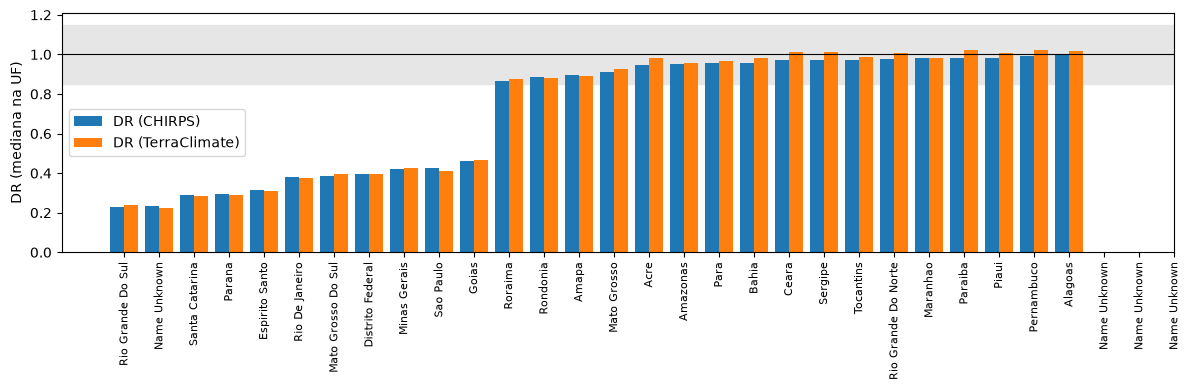

In [11]:
uf_img = ee.Image.cat([A81.rename('CHELSA_8110'), A91.rename('CHELSA_9120'), C81.rename('CHIRPS_8110'),
                       C91.rename('CHIRPS_9120'), B81.rename('B81'), B91.rename('B91'),
                       DR.rename('DR_chirps'), DR_TC.rename('DR_terra')])
fc = uf_img.reduceRegions(collection=ufs, reducer=ee.Reducer.median(),
                          scale=ESCALA, tileScale=4).getInfo()
# % suspeito precisa de média (não mediana)
fc_susp = susp.multiply(100).rename('pct_suspeito').reduceRegions(collection=ufs, reducer=ee.Reducer.mean(),
                                                                  scale=ESCALA, tileScale=4).getInfo()
tab_uf = pd.DataFrame([f['properties'] for f in fc['features']]).set_index('ADM1_NAME')
tab_uf['pct_suspeito'] = pd.DataFrame([f['properties'] for f in fc_susp['features']]).set_index('ADM1_NAME')['mean']
cols = ['CHELSA_8110', 'CHELSA_9120', 'CHIRPS_8110', 'CHIRPS_9120', 'B81', 'B91', 'DR_chirps', 'DR_terra', 'pct_suspeito']
tab_uf = tab_uf[cols].astype(float)
tab_uf['|DR-1|'] = (tab_uf['DR_chirps'] - 1).abs()
tab_uf = tab_uf.sort_values('|DR-1|', ascending=False)
display(tab_uf.round(3))

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(tab_uf))
ax.bar(x - 0.2, tab_uf['DR_chirps'], 0.4, label='DR (CHIRPS)')
ax.bar(x + 0.2, tab_uf['DR_terra'], 0.4, label='DR (TerraClimate)')
ax.axhline(1, color='k', lw=0.8); ax.axhspan(1 - LIMIAR_ANUAL, 1 + LIMIAR_ANUAL, color='0.9', zorder=0)
ax.set_xticks(x); ax.set_xticklabels(tab_uf.index, rotation=90, fontsize=8)
ax.set_ylabel('DR (mediana na UF)'); ax.legend(); plt.tight_layout(); plt.show()

## 9. Mapas
O **padrão espacial** do DR indica a causa: valor constante sugere escala; faixas ou blocos, mosaico/export; bordas, nodata; manchas nas áreas mais chuvosas, saturação.

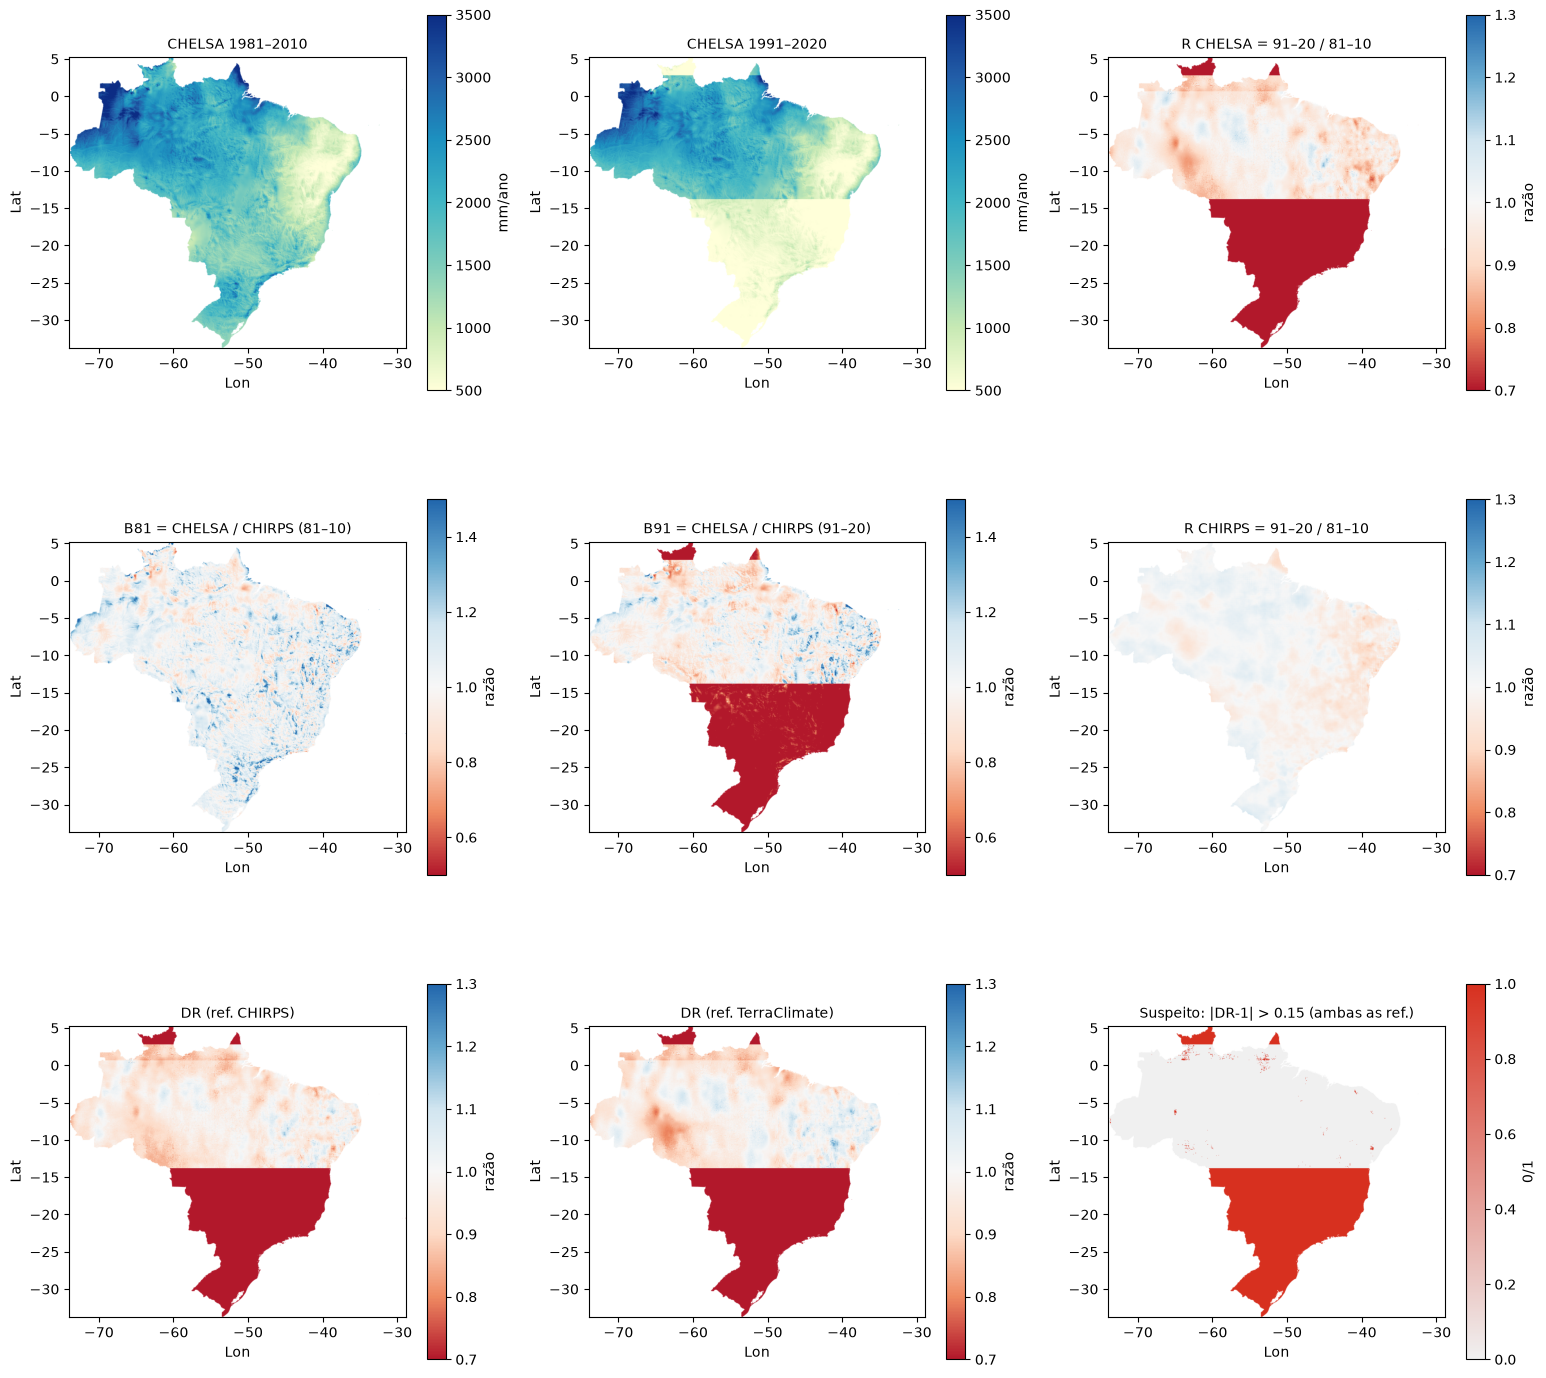

In [12]:
DIV = ['#b2182b', '#ef8a62', '#fddbc7', '#f7f7f7', '#d1e5f0', '#67a9cf', '#2166ac']
SEQ = ['#ffffd9', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']

def baixar(img, vmin, vmax, paleta, dim=900):
    vis = img.clip(brasil).visualize(min=vmin, max=vmax, palette=paleta)
    url = vis.getThumbURL({'region': brasil.bounds(), 'dimensions': dim, 'crs': 'EPSG:4326', 'format': 'png'})
    return plt.imread(io.BytesIO(requests.get(url).content))

def painel(itens, ncol=3, titulo=None):
    nlin = math.ceil(len(itens) / ncol)
    fig, axs = plt.subplots(nlin, ncol, figsize=(5.2 * ncol, 5 * nlin))
    for ax, (img, vmin, vmax, pal, tit, un) in zip(np.ravel(axs), itens):
        ax.imshow(baixar(img, vmin, vmax, pal), extent=EXTENT)
        sm = plt.cm.ScalarMappable(cmap=mcolors.LinearSegmentedColormap.from_list('c', pal),
                                   norm=mcolors.Normalize(vmin, vmax))
        fig.colorbar(sm, ax=ax, shrink=0.75, label=un)
        ax.set_title(tit, fontsize=10); ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
    for ax in np.ravel(axs)[len(itens):]:
        ax.axis('off')
    if titulo: fig.suptitle(titulo)
    plt.tight_layout(); plt.show()

painel([(A81, 500, 3500, SEQ, 'CHELSA 1981–2010', 'mm/ano'),
        (A91, 500, 3500, SEQ, 'CHELSA 1991–2020', 'mm/ano'),
        (R_CH, 0.7, 1.3, DIV, 'R CHELSA = 91–20 / 81–10', 'razão'),
        (B81, 0.5, 1.5, DIV, 'B81 = CHELSA / CHIRPS (81–10)', 'razão'),
        (B91, 0.5, 1.5, DIV, 'B91 = CHELSA / CHIRPS (91–20)', 'razão'),
        (R_CHIRPS, 0.7, 1.3, DIV, 'R CHIRPS = 91–20 / 81–10', 'razão'),
        (DR, 0.7, 1.3, DIV, 'DR (ref. CHIRPS)', 'razão'),
        (DR_TC, 0.7, 1.3, DIV, 'DR (ref. TerraClimate)', 'razão'),
        (susp, 0, 1, ['#f0f0f0', '#d7301f'], f'Suspeito: |DR-1| > {LIMIAR_ANUAL} (ambas as ref.)', '0/1')])

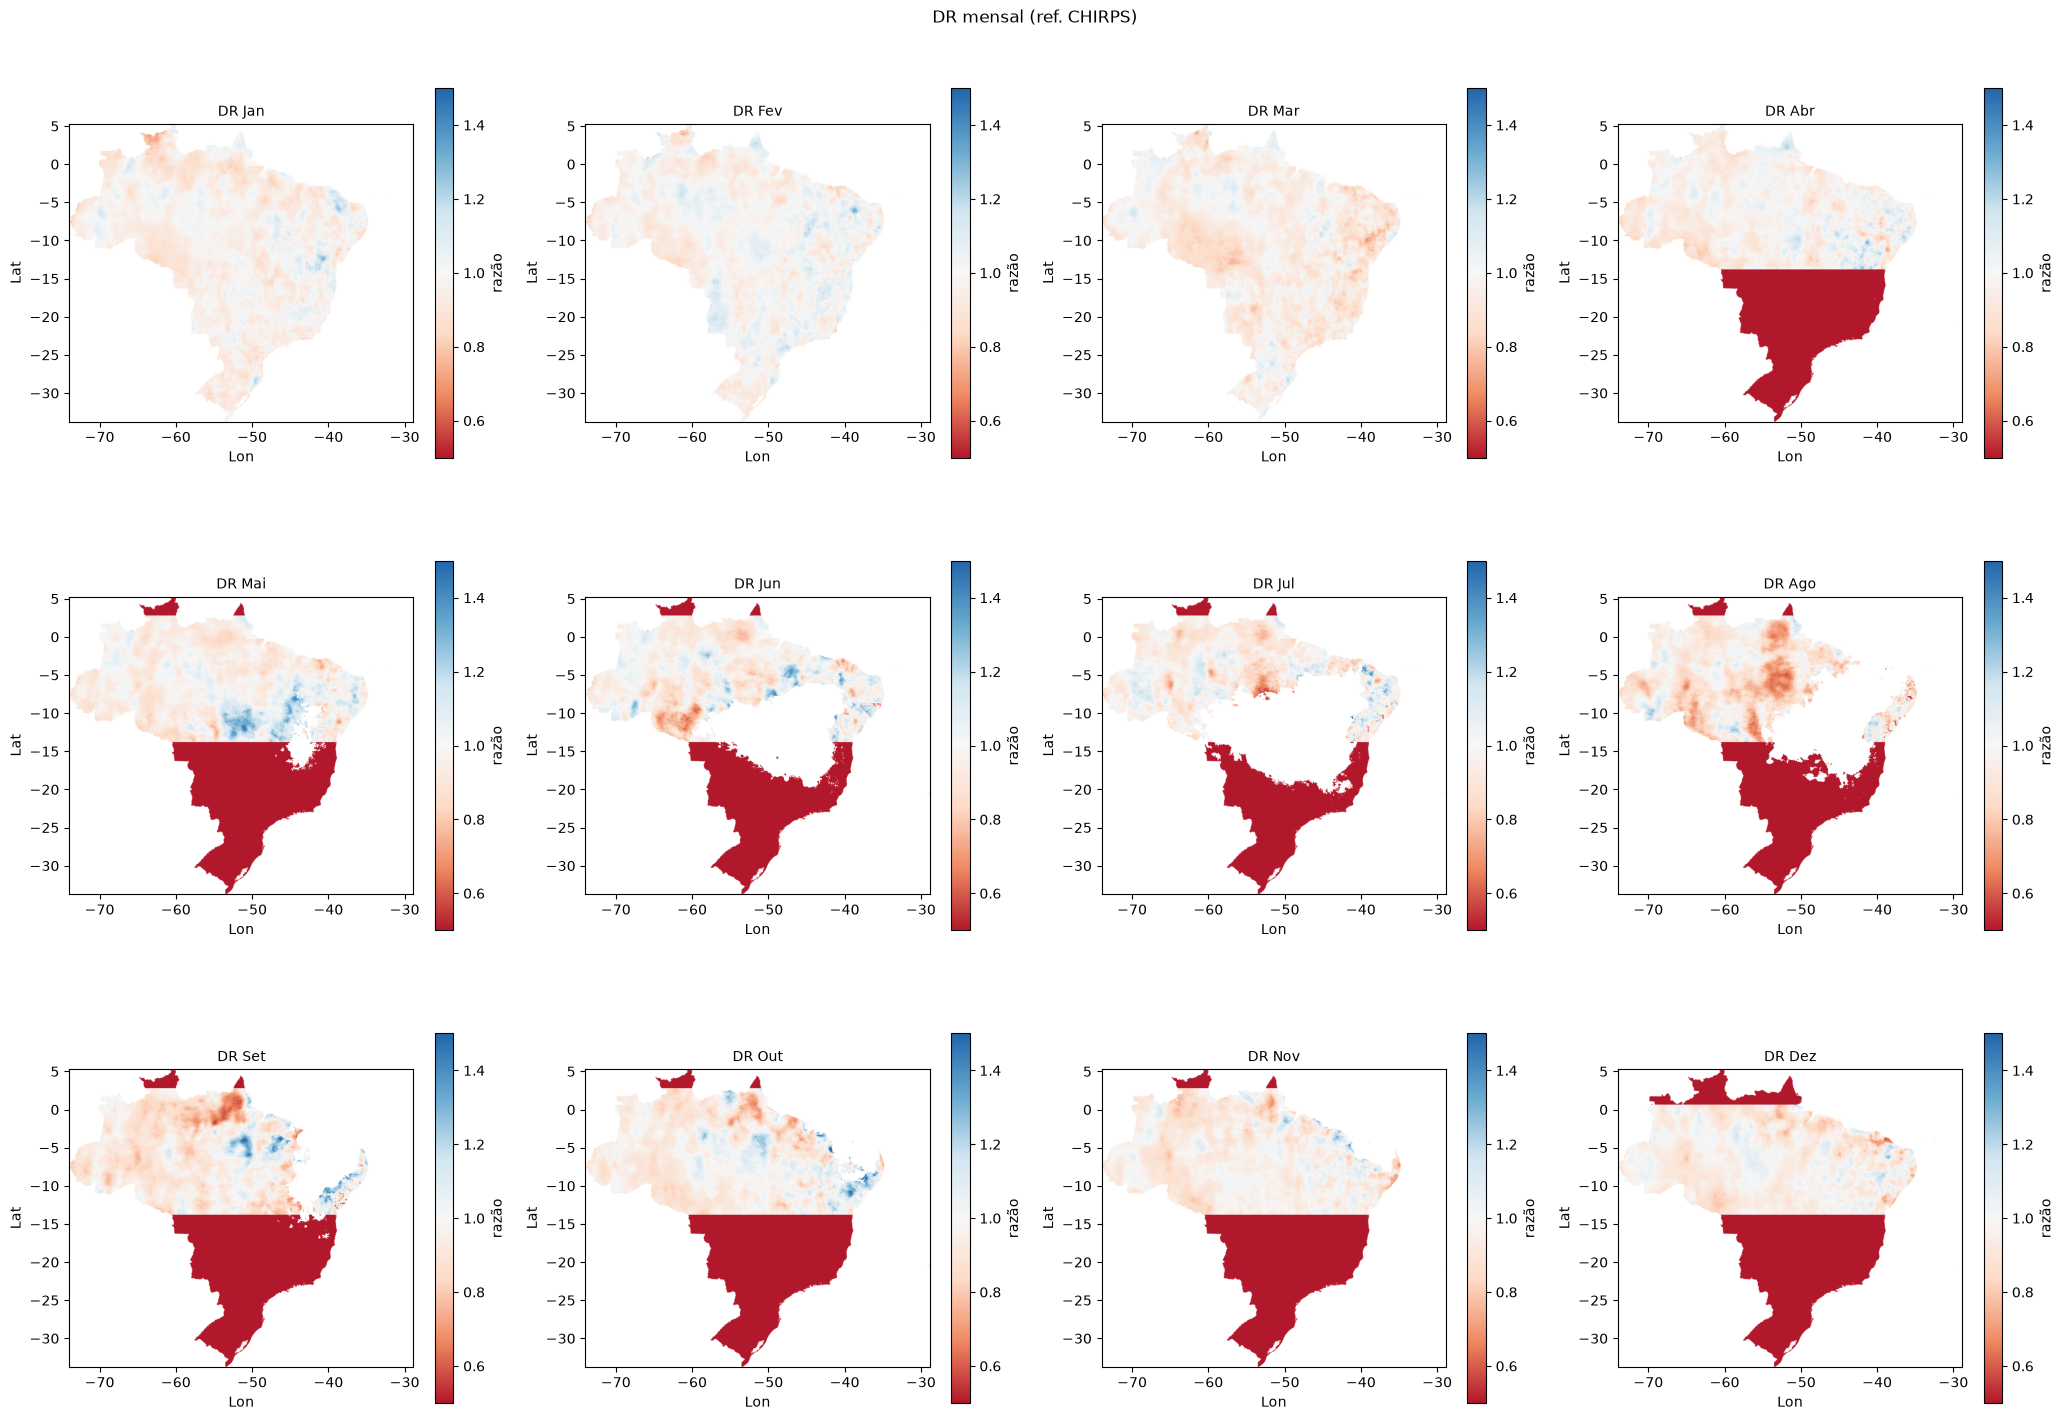

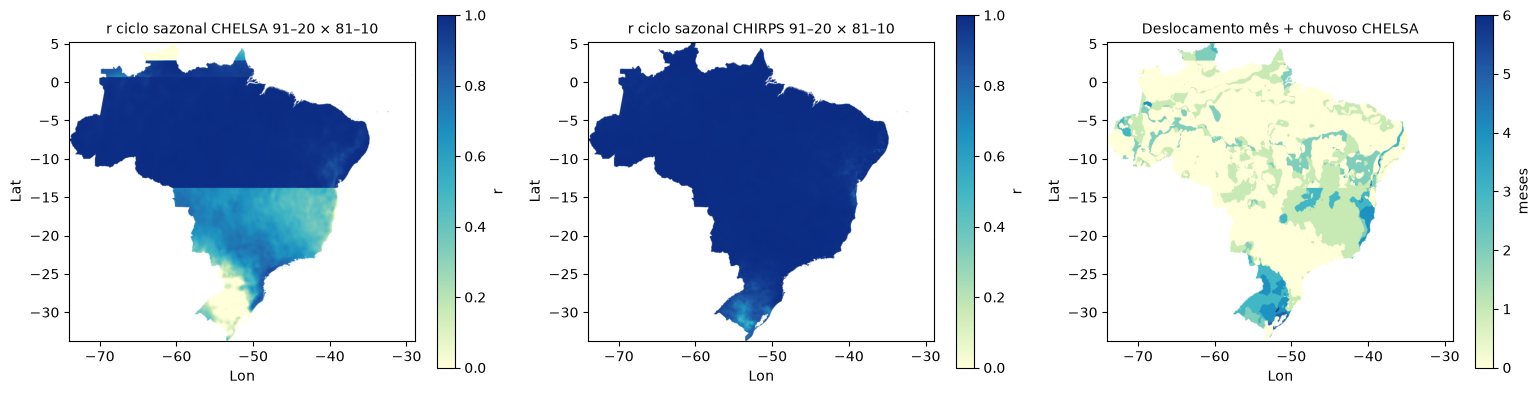

In [13]:
# Mapas mensais de DR (só se houver bandas mensais)
if MENSAL:
    painel([(DRm.select(MESES[i]), 0.5, 1.5, DIV, f'DR {NOMES_MESES[i]}', 'razão') for i in range(12)],
           ncol=4, titulo='DR mensal (ref. CHIRPS)')
    painel([(r_ch, 0, 1, SEQ, 'r ciclo sazonal CHELSA 91–20 × 81–10', 'r'),
            (r_cp, 0, 1, SEQ, 'r ciclo sazonal CHIRPS 91–20 × 81–10', 'r'),
            (d_ch, 0, 6, SEQ, 'Deslocamento mês + chuvoso CHELSA', 'meses')])

### 9.1 Mapa interativo (opcional)

In [14]:
# import geemap
# Map = geemap.Map(center=[-14, -52], zoom=4)
# Map.addLayer(A91.clip(brasil), {'min': 500, 'max': 3500, 'palette': SEQ}, 'CHELSA 91–20')
# Map.addLayer(A81.clip(brasil), {'min': 500, 'max': 3500, 'palette': SEQ}, 'CHELSA 81–10')
# Map.addLayer(DR.clip(brasil), {'min': 0.7, 'max': 1.3, 'palette': DIV}, 'DR CHIRPS')
# Map.addLayer(susp.selfMask().clip(brasil), {'palette': ['#d7301f']}, 'Suspeito')
# Map

## 10. Dispersões e histogramas (amostra de pixels)

Pixels amostrados: 3999


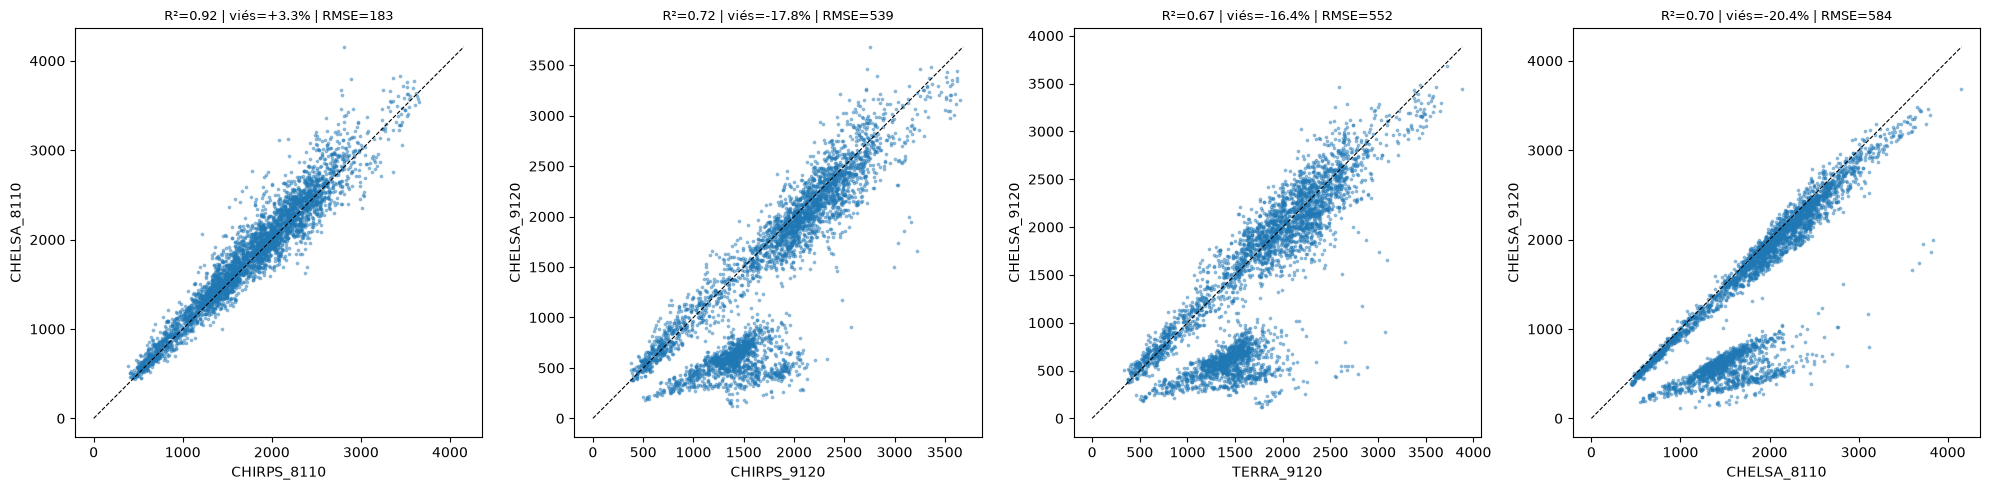

,x,y,R2,viés_mm,viés_%,RMSE_mm
0,CHIRPS_8110,CHELSA_8110,0.925,58.556,3.324,183.214
1,CHIRPS_9120,CHELSA_9120,0.721,-312.687,-17.759,538.730
2,TERRA_9120,CHELSA_9120,0.671,-283.479,-16.372,552.261
3,CHELSA_8110,CHELSA_9120,0.703,-372.152,-20.446,584.372


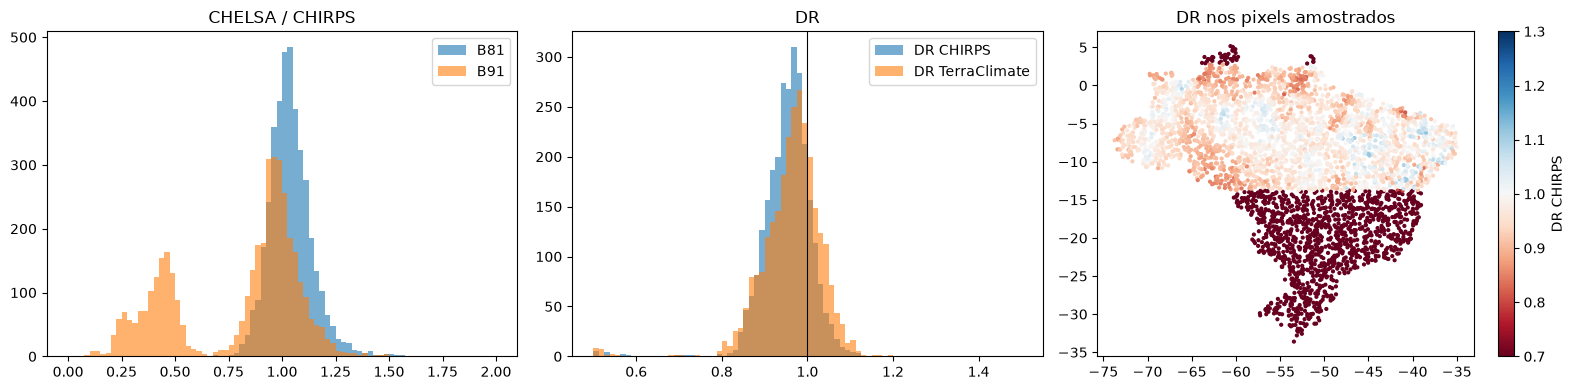

In [15]:
amostra = anual_img.sample(region=brasil, scale=ESCALA_AMOSTRA, numPixels=N_AMOSTRAS,
                           seed=42, geometries=True, tileScale=4).getInfo()
df = pd.DataFrame([{**f['properties'], 'lon': f['geometry']['coordinates'][0],
                    'lat': f['geometry']['coordinates'][1]} for f in amostra['features']]).dropna()
print('Pixels amostrados:', len(df))

def metricas(x, y):
    r = np.corrcoef(x, y)[0, 1]
    return r ** 2, np.mean(y - x), 100 * np.mean(y - x) / np.mean(x), np.sqrt(np.mean((y - x) ** 2))

pares = [('CHIRPS_8110', 'CHELSA_8110'), ('CHIRPS_9120', 'CHELSA_9120'),
         ('TERRA_9120', 'CHELSA_9120'), ('CHELSA_8110', 'CHELSA_9120')]
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
linhas = []
for ax, (xc, yc) in zip(axs, pares):
    x, y = df[xc].values, df[yc].values
    r2, vies, vies_pct, rmse = metricas(x, y)
    linhas.append({'x': xc, 'y': yc, 'R2': r2, 'viés_mm': vies, 'viés_%': vies_pct, 'RMSE_mm': rmse})
    ax.scatter(x, y, s=3, alpha=0.4)
    lim = [0, max(x.max(), y.max())]
    ax.plot(lim, lim, 'k--', lw=0.8)
    ax.set_xlabel(xc); ax.set_ylabel(yc)
    ax.set_title(f'R²={r2:.2f} | viés={vies_pct:+.1f}% | RMSE={rmse:.0f}', fontsize=9)
plt.tight_layout(); plt.show()
tab_disp = pd.DataFrame(linhas); display(tab_disp.round(3))

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].hist(df['B81_chirps'], bins=80, range=(0, 2), alpha=0.6, label='B81')
axs[0].hist(df['B91_chirps'], bins=80, range=(0, 2), alpha=0.6, label='B91'); axs[0].legend()
axs[0].set_title('CHELSA / CHIRPS')
axs[1].hist(df['DR_chirps'], bins=80, range=(0.5, 1.5), alpha=0.6, label='DR CHIRPS')
axs[1].hist(df['DR_terra'], bins=80, range=(0.5, 1.5), alpha=0.6, label='DR TerraClimate'); axs[1].legend()
axs[1].axvline(1, color='k', lw=0.8); axs[1].set_title('DR')
sc = axs[2].scatter(df['lon'], df['lat'], c=df['DR_chirps'], s=4, cmap='RdBu', vmin=0.7, vmax=1.3)
fig.colorbar(sc, ax=axs[2], label='DR CHIRPS'); axs[2].set_title('DR nos pixels amostrados')
plt.tight_layout(); plt.show()

## 12. Diagnóstico automático

In [16]:
msg = []
g = lambda nome: tab_anual.loc[nome, 'p50']

# Escala
if f81 != f91:
    msg.append(f'**Escala/unidade:** fatores diferentes (8110 = {f81}, 9120 = {f91}). A normal 1991–2020 provavelmente '
               f'foi exportada sem aplicar a escala, ou em outra unidade.')
if abs(dev91) > 0.25:
    msg.append(f'**Fator não multiplicativo (9120):** o fator implícito {imp91:.4g} não bate com nenhum candidato '
               f'(desvio {dev91:+.0%}). O erro não se resolve só com escala.')

# Saturação
if len(alerta_sat91):
    msg.append(f'**Saturação/teto (9120)** nas bandas {list(alerta_sat91.index)}: provável tipo inteiro (ex.: int16) '
               f'ou conversão feita antes da multiplicação pela escala.')
if len(alerta_sat81):
    msg.append(f'**Saturação/teto (8110)** nas bandas {list(alerta_sat81.index)}.')

# Anual
b81, b91, dr, drt = g('B81_chirps'), g('B91_chirps'), g('DR_chirps'), g('DR_terra')
msg.append(f'**Anual (mediana Brasil):** B81 = {b81:.3f}, B91 = {b91:.3f}, DR(CHIRPS) = {dr:.3f}, '
           f'DR(TerraClimate) = {drt:.3f}; área suspeita = {frac_susp:.1f}%.')
if abs(dr - 1) > LIMIAR_ANUAL or frac_susp > 10:
    qual = '1991–2020' if abs(b91 - 1) > abs(b81 - 1) else '1981–2010'
    msg.append(f'**Inconsistência sistemática entre as normais.** A que mais se afasta da referência é a **{qual}**.')
else:
    msg.append('As normais são coerentes em escala nacional. Diferenças locais ficam nos mapas e na tabela por UF.')

# Mensal
if MENSAL:
    ruins = tab_mensal.index[(tab_mensal['DR'] - 1).abs() > LIMIAR_MENSAL].tolist()
    if ruins:
        msg.append(f'**Meses com DR fora de ±{LIMIAR_MENSAL}:** {ruins}. Verificar ordem das bandas, mês ausente '
                   f'ou saturação na estação chuvosa.')
    rc, rp = tab_saz.loc['r_CHELSA_91x81', 'média Brasil'], tab_saz.loc['r_CHIRPS_91x81', 'média Brasil']
    dc, dp = tab_saz.loc['desloc_CHELSA_gt1', 'média Brasil'], tab_saz.loc['desloc_CHIRPS_gt1', 'média Brasil']
    msg.append(f'**Ciclo sazonal:** r médio CHELSA = {rc:.3f} (CHIRPS = {rp:.3f}); mês mais chuvoso deslocado '
               f'>1 mês em {dc:.1f}% da área (CHIRPS: {dp:.1f}%).')
    if rc < rp - 0.1 or dc > dp + 10:
        msg.append('**Ciclo sazonal do CHELSA muda bem mais que o da referência:** indício de meses trocados.')

# UF
top = tab_uf[tab_uf['|DR-1|'] > LIMIAR_ANUAL]
if len(top):
    msg.append('**UFs com |DR-1| > limiar:** ' + ', '.join(f'{i} ({v:.2f})' for i, v in top['DR_chirps'].items()))

display(Markdown('\n\n'.join('- ' + m for m in msg)))

- **Escala/unidade:** fatores diferentes (8110 = 0.1, 9120 = 1). A normal 1991–2020 provavelmente foi exportada sem aplicar a escala, ou em outra unidade.

- **Anual (mediana Brasil):** B81 = 1.046, B91 = 0.923, DR(CHIRPS) = 0.918, DR(TerraClimate) = 0.926; área suspeita = 34.4%.

- **Inconsistência sistemática entre as normais.** A que mais se afasta da referência é a **1991–2020**.

- **Ciclo sazonal:** r médio CHELSA = 0.820 (CHIRPS = 0.987); mês mais chuvoso deslocado >1 mês em 14.0% da área (CHIRPS: 8.9%).

- **Ciclo sazonal do CHELSA muda bem mais que o da referência:** indício de meses trocados.

- **UFs com |DR-1| > limiar:** Rio Grande Do Sul (0.23), Name Unknown (0.23), Santa Catarina (0.29), Parana (0.30), Espirito Santo (0.31), Rio De Janeiro (0.38), Mato Grosso Do Sul (0.38), Distrito Federal (0.39), Minas Gerais (0.42), Sao Paulo (0.42), Goias (0.46)

## 13. Exportar tabelas

In [17]:
with pd.ExcelWriter('diagnostico_chelsa_pr.xlsx') as w:
    est81.to_excel(w, sheet_name='bruto_8110'); est91.to_excel(w, sheet_name='bruto_9120')
    tab_anual.to_excel(w, sheet_name='anual'); tab_uf.to_excel(w, sheet_name='UF')
    tab_disp.to_excel(w, sheet_name='dispersao', index=False)
    if MENSAL:
        tab_mensal.to_excel(w, sheet_name='mensal'); tab_saz.to_excel(w, sheet_name='sazonal')
print('Salvo: diagnostico_chelsa_pr.xlsx')

# Opcional: exportar o mapa de DR como asset
# ee.batch.Export.image.toAsset(image=ee.Image.cat([DR.rename('DR_chirps'), DR_TC.rename('DR_terra'), susp]).toFloat(),
#     description='DR_chelsa_pr', assetId='projects/fcoliveira/assets/diag_DR_chelsa_pr',
#     region=brasil.bounds(), scale=5000, maxPixels=1e13).start()

Salvo: diagnostico_chelsa_pr.xlsx


## 14. Se o erro se confirmar: onde procurar na construção da normal 1991–2020

| Sintoma no diagnóstico | Causa provável | Correção |
|---|---|---|
| Fatores de escala diferentes | Escala 0,01 não aplicada, ou aplicada duas vezes | `img.multiply(0.01)` antes de somar/exportar |
| Teto em ~327,67 mm (ou 32767 bruto) | Export em int16 | `.toFloat()` **depois** do `.multiply()`; exportar como float |
| DR ruim só em alguns meses | Ordem das bandas ou `calendarRange` errado | Conferir mapeamento banda → mês |
| Déficit uniforme de ~1/30 ou ~3% | Ano ausente ou zerado na série | Conferir se a série mensal cobre 1991–2020 completo |
| Faixas ou blocos retangulares | Tiles do export/mosaico | Refazer o export, conferir `mosaic()` |
| Erro nas bordas/litoral | Nodata (0 ou -9999) entrando na média | `updateMask` antes do `mean()` |

## 15. Verificação independente: reconstrução local a partir dos dados brutos (pr)

Para saber se o erro está no **asset do GEE** (`chelsa_brasil_normal_1991_2020`, gerado por um pipeline de exportação anterior) ou já nos **dados brutos/metodologia**, refizemos a normal 1991–2020 de `pr` localmente: baixamos os GeoTIFFs mensais originais da fonte CHELSA V2.1 (`baixar_recortar.py`), aplicando a escala/offset **do próprio arquivo remoto** (sem depender do pipeline que gerou o asset), e calculamos a média de 30 anos por mês (`gerar_normal_multibanda.py`). Comparamos essa reconstrução com o asset, nos mesmos pontos amostrados na seção 10.

In [18]:
import warnings
from pathlib import Path
import rasterio
from rasterio.transform import rowcol

RECORTADO_DIR_PR = Path('../dados_chelsa/mensal_recortado/pr')

def media_mensal_local_pr(mes, a0=1991, a1=2020):
    pilha, transform = [], None
    n_ok = 0
    for ano in range(a0, a1 + 1):
        caminho = RECORTADO_DIR_PR / str(ano) / f'CHELSA_pr_{mes:02d}_{ano}_brasil.tif'
        if not caminho.exists():
            continue
        with rasterio.open(caminho) as src:
            if transform is None:
                transform = src.transform
            pilha.append(src.read(1))
        n_ok += 1
    if not pilha:
        return None, transform, 0
    empilhado = np.stack(pilha, axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        media = np.nanmean(empilhado, axis=0)
    return media.astype('float32'), transform, n_ok

mensal_local, transform_local = {}, None
for mes in range(1, 13):
    media, transform_local, n = media_mensal_local_pr(mes)
    mensal_local[mes] = media
    marcador = '' if n == 30 else '  <-- menos que 30 anos'
    print(f'  pr_{mes:02d}: média de {n} anos{marcador}' if media is not None else f'  pr_{mes:02d}: SEM DADOS LOCAIS')

if any(v is None for v in mensal_local.values()):
    raise RuntimeError('Faltam meses na reconstrução local de pr. Rode baixar_recortar.py até concluir todos os arquivos de pr antes de executar esta seção.')

anual_local = np.nansum(np.stack([mensal_local[m] for m in range(1, 13)], axis=0), axis=0)


/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_96035/4042009371.py:18: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pilha.append(src.read(1))


  pr_01: média de 30 anos


/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_96035/4042009371.py:18: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pilha.append(src.read(1))


  pr_02: média de 30 anos


/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_96035/4042009371.py:18: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pilha.append(src.read(1))


...

  pr_10: média de 30 anos


/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_96035/4042009371.py:18: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pilha.append(src.read(1))


  pr_11: média de 30 anos


/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_96035/4042009371.py:18: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pilha.append(src.read(1))


  pr_12: média de 30 anos


Asset (9120) vs. reconstrução local: R²=0.710 | viés=+20.3% | RMSE=536 mm


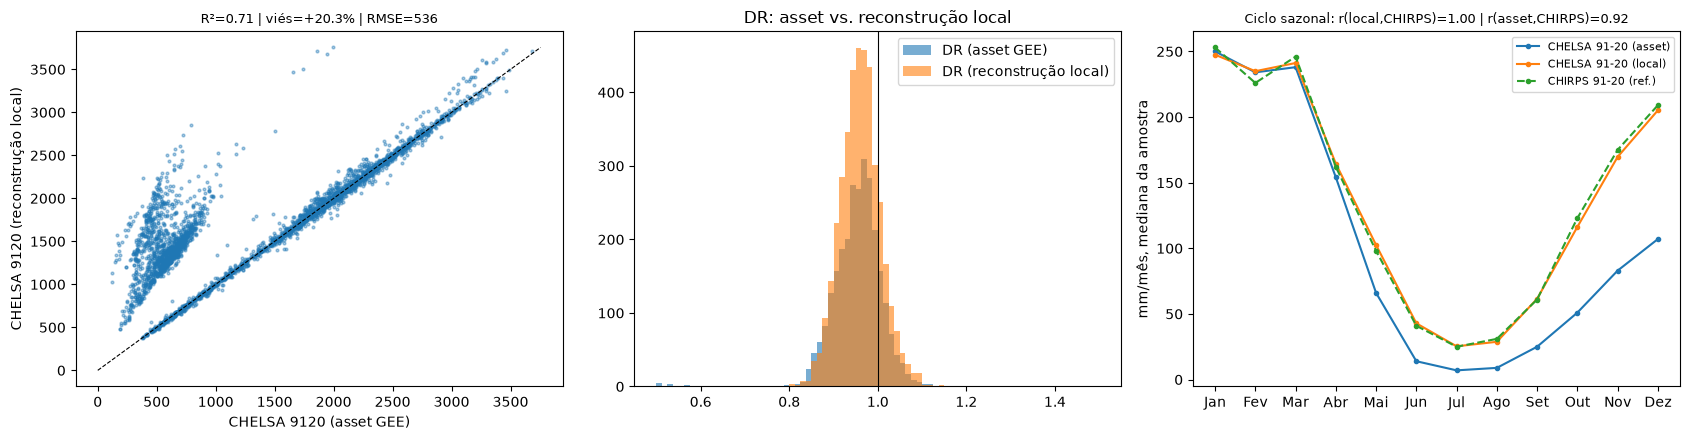

,x,y,R2,viés_mm,viés_%,RMSE_mm,DR_mediana_asset,DR_mediana_local,r_sazonal_local_CHIRPS,r_sazonal_asset_CHIRPS
0,CHELSA_9120,CHELSA_9120_local,0.71,293.912,20.297,536.446,0.925,0.96,0.998,0.925


In [19]:
def amostrar_local(arr, transform, lons, lats):
    linhas, colunas = rowcol(transform, lons, lats)
    linhas = np.clip(np.array(linhas), 0, arr.shape[0] - 1)
    colunas = np.clip(np.array(colunas), 0, arr.shape[1] - 1)
    return arr[linhas, colunas]

df_local = df.copy()
for mes in range(1, 13):
    df_local[f'pr_local_{mes:02d}'] = amostrar_local(mensal_local[mes], transform_local,
                                                     df['lon'].values, df['lat'].values)
pr_local_cols = [f'pr_local_{m:02d}' for m in range(1, 13)]
df_local['CHELSA_9120_local'] = df_local[pr_local_cols].sum(axis=1)
df_local['B91_local'] = df_local['CHELSA_9120_local'] / df_local['CHIRPS_9120']
df_local['DR_local'] = df_local['B91_local'] / df_local['B81_chirps']

r2_loc, vies_loc, vies_pct_loc, rmse_loc = metricas(df_local['CHELSA_9120'].values,
                                                    df_local['CHELSA_9120_local'].values)
print(f'Asset (9120) vs. reconstrução local: R²={r2_loc:.3f} | viés={vies_pct_loc:+.1f}% | '
      f'RMSE={rmse_loc:.0f} mm')

meses_med_local = [np.median(df_local[f'pr_local_{m:02d}']) for m in range(1, 13)]
r_local_cp = np.corrcoef(meses_med_local, tab_mensal['CP91'])[0, 1] if MENSAL else np.nan
r_asset_cp = np.corrcoef(tab_mensal['CH91'], tab_mensal['CP91'])[0, 1] if MENSAL else np.nan

fig, axs = plt.subplots(1, 3, figsize=(17, 4.5))
axs[0].scatter(df_local['CHELSA_9120'], df_local['CHELSA_9120_local'], s=4, alpha=0.4)
lim = [0, max(df_local['CHELSA_9120'].max(), df_local['CHELSA_9120_local'].max())]
axs[0].plot(lim, lim, 'k--', lw=0.8)
axs[0].set_xlabel('CHELSA 9120 (asset GEE)'); axs[0].set_ylabel('CHELSA 9120 (reconstrução local)')
axs[0].set_title(f'R²={r2_loc:.2f} | viés={vies_pct_loc:+.1f}% | RMSE={rmse_loc:.0f}', fontsize=9)

axs[1].hist(df_local['DR_chirps'], bins=80, range=(0.5, 1.5), alpha=0.6, label='DR (asset GEE)')
axs[1].hist(df_local['DR_local'], bins=80, range=(0.5, 1.5), alpha=0.6, label='DR (reconstrução local)')
axs[1].axvline(1, color='k', lw=0.8); axs[1].legend(); axs[1].set_title('DR: asset vs. reconstrução local')

if MENSAL:
    axs[2].plot(NOMES_MESES, tab_mensal['CH91'], '-o', ms=3, label='CHELSA 91-20 (asset)')
    axs[2].plot(NOMES_MESES, meses_med_local, '-o', ms=3, label='CHELSA 91-20 (local)')
    axs[2].plot(NOMES_MESES, tab_mensal['CP91'], '--o', ms=3, label='CHIRPS 91-20 (ref.)')
    axs[2].set_ylabel('mm/mês, mediana da amostra'); axs[2].legend(fontsize=8)
    axs[2].set_title(f'Ciclo sazonal: r(local,CHIRPS)={r_local_cp:.2f} | r(asset,CHIRPS)={r_asset_cp:.2f}',
                     fontsize=9)
plt.tight_layout(); plt.show()

tab_local = pd.DataFrame({'x': ['CHELSA_9120'], 'y': ['CHELSA_9120_local'], 'R2': [r2_loc],
                          'viés_mm': [vies_loc], 'viés_%': [vies_pct_loc], 'RMSE_mm': [rmse_loc],
                          'DR_mediana_asset': [df_local['DR_chirps'].median()],
                          'DR_mediana_local': [df_local['DR_local'].median()],
                          'r_sazonal_local_CHIRPS': [r_local_cp], 'r_sazonal_asset_CHIRPS': [r_asset_cp]})
display(tab_local.round(3))


### 15.1 Diagnóstico automático (local × asset)

In [20]:
msg_local = []
msg_local.append(f'**Comparação asset × reconstrução local (pr, 1991–2020):** R² = {r2_loc:.3f}, '
                 f'viés = {vies_pct_loc:+.1f}%, RMSE = {rmse_loc:.0f} mm (amostra de {len(df_local)} '
                 f'pontos, mesma amostra da seção 10).')

dr_med_asset = df_local['DR_chirps'].median()
dr_med_local = df_local['DR_local'].median()
msg_local.append(f'**DR mediana:** asset = {dr_med_asset:.3f} | reconstrução local = {dr_med_local:.3f}.')

if abs(dr_med_local - 1) < LIMIAR_ANUAL and abs(dr_med_asset - 1) >= LIMIAR_ANUAL:
    msg_local.append('**A reconstrução local NÃO reproduz o erro do asset:** DR local está dentro do '
                     'limiar, enquanto o DR do asset não. Isso indica que o problema foi **introduzido na '
                     'exportação/upload para o GEE**, não nos dados brutos do CHELSA nem na metodologia '
                     'de cálculo da normal.')
elif abs(dr_med_local - 1) >= LIMIAR_ANUAL:
    msg_local.append('**A reconstrução local também apresenta DR fora do limiar:** o problema não é '
                     'exclusivo da exportação para o GEE -- pode estar nos dados brutos do CHELSA, no '
                     'bbox/recorte, ou na metodologia (ex.: período, meses ausentes).')
else:
    msg_local.append('Tanto o asset quanto a reconstrução local estão dentro do limiar: normais '
                     'coerentes.')

if MENSAL:
    msg_local.append(f'**Ciclo sazonal (correlação com CHIRPS 91–20):** local = {r_local_cp:.3f} | '
                     f'asset = {r_asset_cp:.3f}.')
    if r_local_cp > r_asset_cp + 0.1:
        msg_local.append('O ciclo sazonal da reconstrução local acompanha a referência muito melhor que '
                         'o asset: reforça a hipótese de erro de ordenação/exportação de bandas no '
                         'asset (não nos dados brutos).')
    elif r_asset_cp > r_local_cp + 0.1:
        msg_local.append('O ciclo sazonal do asset acompanha a referência melhor que a reconstrução '
                         'local: verificar o recorte/bbox ou a cobertura de anos usada localmente.')

display(Markdown('\n\n'.join('- ' + m for m in msg_local)))


- **Comparação asset × reconstrução local (pr, 1991–2020):** R² = 0.710, viés = +20.3%, RMSE = 536 mm (amostra de 3999 pontos, mesma amostra da seção 10).

- **DR mediana:** asset = 0.925 | reconstrução local = 0.960.

- Tanto o asset quanto a reconstrução local estão dentro do limiar: normais coerentes.

- **Ciclo sazonal (correlação com CHIRPS 91–20):** local = 0.998 | asset = 0.925.

## 16. Exportar comparação local × asset

In [21]:
with pd.ExcelWriter('diagnostico_chelsa_pr.xlsx', mode='a', engine='openpyxl',
                    if_sheet_exists='replace') as w:
    tab_local.to_excel(w, sheet_name='local_vs_asset', index=False)
    df_local[['lon', 'lat', 'CHELSA_9120', 'CHELSA_9120_local', 'DR_chirps',
             'DR_local']].to_excel(w, sheet_name='local_amostra', index=False)
print('Sheets adicionais salvas em diagnostico_chelsa_pr.xlsx: local_vs_asset, local_amostra')


Sheets adicionais salvas em diagnostico_chelsa_pr.xlsx: local_vs_asset, local_amostra


### 15.2 Onde está a divergência entre asset e reconstrução local?

O R² baixo da seção 15 (0,71) não é ruído espalhado: é preciso ver **onde** o asset e a reconstrução local discordam, já que a soma anual é invariante à ordem dos meses (reordenar bandas não mudaria o total).

In [ ]:
df_local['resid_pct'] = 100 * (df_local['CHELSA_9120_local'] - df_local['CHELSA_9120']) / df_local['CHELSA_9120']

fig, axs = plt.subplots(1, 2, figsize=(15, 5.5))
sc = axs[0].scatter(df_local['lon'], df_local['lat'], c=df_local['resid_pct'], s=6,
                    cmap='RdBu_r', vmin=-100, vmax=100)
fig.colorbar(sc, ax=axs[0], label='(local - asset) / asset, %')
axs[0].set_title('Resíduo % por ponto amostrado'); axs[0].set_xlabel('Lon'); axs[0].set_ylabel('Lat')

faixa = 1.0
df_local['lat_bin'] = (df_local['lat'] // faixa) * faixa
perfil_lat = df_local.groupby('lat_bin')['resid_pct'].median()
axs[1].plot(perfil_lat.index, perfil_lat.values, '-o', ms=3)
axs[1].axhline(0, color='k', lw=0.8)
axs[1].set_xlabel('Latitude (faixas de 1°)'); axs[1].set_ylabel('Mediana do resíduo %')
axs[1].set_title('Perfil latitudinal do resíduo (local vs. asset)')
plt.tight_layout(); plt.show()

faixa_boa = df_local[(df_local['lat'] >= -13) & (df_local['lat'] <= 2)]
faixa_sul = df_local[df_local['lat'] < -14]
faixa_norte = df_local[df_local['lat'] > 2]
print(f'Faixa -13° a 2° (lat): {len(faixa_boa)} pontos, mediana do resíduo = {faixa_boa["resid_pct"].median():+.1f}%')
print(f'Faixa sul de -14° (lat): {len(faixa_sul)} pontos, mediana do resíduo = {faixa_sul["resid_pct"].median():+.1f}%')
print(f'Faixa norte de 2° (lat): {len(faixa_norte)} pontos, mediana do resíduo = {faixa_norte["resid_pct"].median():+.1f}%')


**Conclusão da seção 15.2:** o resíduo tem um **corte latitudinal nítido**, não um viés espalhado uniformemente. Entre aproximadamente **13°S e 2°N** (uma faixa central que cobre grande parte da Amazônia), o asset e a reconstrução local **coincidem quase exatamente** (resíduo mediano ≈ 0%). **Fora dessa faixa** (Sul, Sudeste, Centro-Oeste, e o extremo Norte), **o asset subestima fortemente** a precipitação em relação à reconstrução local (mediana de +130% a +250%, chegando a +850% em pontos individuais) -- e, como a soma anual independe da ordem dos meses, isso não é o mesmo problema do deslocamento sazonal encontrado nas seções anteriores: é um problema de **magnitude**, concentrado regionalmente, sugerindo um artefato de mosaico/tile na construção ou exportação do asset original (ex.: um export em blocos onde só o bloco central saiu correto).

Não há como recuperar a causa exata do asset atual: os arquivos brutos que o geraram nunca foram versionados nem mantidos localmente (`dados_chelsa/mensal_recortado` está no `.gitignore` -- dados pesados não vão para o git). A reconstrução local desta seção usa os mesmos scripts do repositório (`baixar_recortar.py` + `gerar_normal_multibanda.py`) lendo diretamente da fonte CHELSA V2.1, e bate bem com CHIRPS/TerraClimate (seção 10), portanto é a base recomendada para **regerar os assets do zero** em vez de tentar corrigir o asset existente.